In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.model_selection import train_test_split
from sklearn.feature_extraction.text import TfidfVectorizer
from sklearn.linear_model import LogisticRegression
from sklearn.svm import LinearSVC
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import (accuracy_score, classification_report,
                             confusion_matrix, ConfusionMatrixDisplay)


In [2]:
df_youtube = pd.read_csv("youtube_all_labeled.csv")
df_gnews   = pd.read_csv("Gnews_all_labeled.csv")

df_youtube = df_youtube[["text_clean", "label"]]
df_gnews   = df_gnews[["text_clean", "label"]]

df = pd.concat([df_youtube, df_gnews], ignore_index=True)
df = df.dropna(subset=["text_clean", "label"])
df["text_clean"] = df["text_clean"].astype(str)
df["label"]      = df["label"].astype(int)

print("Dataset shape:", df.shape)
print(df["label"].value_counts())

Dataset shape: (3891, 2)
label
-1    2260
 0     839
 1     792
Name: count, dtype: int64


In [3]:
X = df["text_clean"]
y = df["label"]

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42
)

vectorizer  = TfidfVectorizer(max_features=5000, ngram_range=(1,2), min_df=2, max_df=0.95)
X_train_vec = vectorizer.fit_transform(X_train)
X_test_vec  = vectorizer.transform(X_test)

Baseline Model - Logistic Regression


In [4]:
lr_model = LogisticRegression(max_iter=1000, class_weight="balanced", random_state=42)
lr_model.fit(X_train_vec, y_train)
y_pred_lr = lr_model.predict(X_test_vec)

accuracy  = accuracy_score(y_test, y_pred_lr)
lr_report = classification_report(y_test, y_pred_lr, output_dict=True)
precision = lr_report["weighted avg"]["precision"]
recall    = lr_report["weighted avg"]["recall"]
f1        = lr_report["weighted avg"]["f1-score"]

print("Logistic Regression Accuracy:", round(accuracy, 4))
print(classification_report(y_test, y_pred_lr, target_names=["negative","neutral","positive"]))

Logistic Regression Accuracy: 0.7112
              precision    recall  f1-score   support

    negative       0.81      0.76      0.79       443
     neutral       0.58      0.68      0.63       176
    positive       0.61      0.61      0.61       160

    accuracy                           0.71       779
   macro avg       0.67      0.68      0.67       779
weighted avg       0.72      0.71      0.71       779



Classification Model - Support Vector Machine (SVM)

In [5]:
svm_model = LinearSVC(C=1.0, class_weight="balanced", random_state=42)
svm_model.fit(X_train_vec, y_train)
y_pred_svm = svm_model.predict(X_test_vec)

svm_accuracy = accuracy_score(y_test, y_pred_svm)
svm_report   = classification_report(y_test, y_pred_svm, output_dict=True)
report_df    = pd.DataFrame(svm_report).T

print("SVM Accuracy:", round(svm_accuracy, 4))
print(classification_report(y_test, y_pred_svm, target_names=["negative","neutral","positive"]))

SVM Accuracy: 0.7227
              precision    recall  f1-score   support

    negative       0.78      0.82      0.80       443
     neutral       0.65      0.61      0.63       176
    positive       0.63      0.58      0.60       160

    accuracy                           0.72       779
   macro avg       0.69      0.67      0.68       779
weighted avg       0.72      0.72      0.72       779



Classification Model - Random Forest


In [6]:
rf_model = RandomForestClassifier(n_estimators=100, class_weight="balanced", random_state=42)
rf_model.fit(X_train_vec, y_train)
y_pred_rf = rf_model.predict(X_test_vec)

rf_accuracy = accuracy_score(y_test, y_pred_rf)
rf_report   = classification_report(y_test, y_pred_rf, output_dict=True)
rf_precision = rf_report["weighted avg"]["precision"]
rf_recall    = rf_report["weighted avg"]["recall"]
rf_f1        = rf_report["weighted avg"]["f1-score"]

print("Random Forest Accuracy:", round(rf_accuracy, 4))
print(classification_report(y_test, y_pred_rf, target_names=["negative","neutral","positive"]))

Random Forest Accuracy: 0.6945
              precision    recall  f1-score   support

    negative       0.71      0.88      0.79       443
     neutral       0.62      0.57      0.59       176
    positive       0.77      0.31      0.44       160

    accuracy                           0.69       779
   macro avg       0.70      0.59      0.61       779
weighted avg       0.70      0.69      0.67       779



Compare Models & Selection


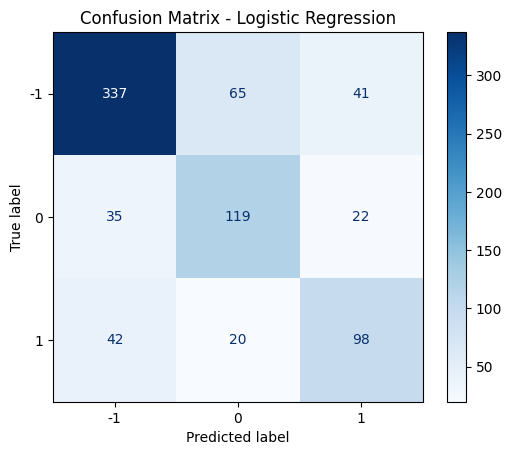

In [7]:
cm_lr = confusion_matrix(y_test, y_pred_lr)
disp_lr = ConfusionMatrixDisplay(confusion_matrix=cm_lr, display_labels=[-1, 0, 1])
disp_lr.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Logistic Regression")
plt.show()

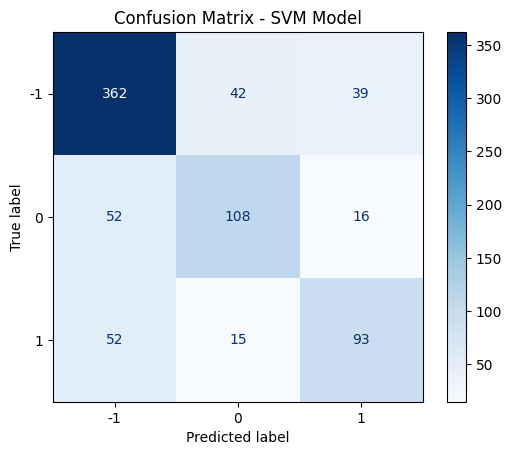

In [8]:
cm   = confusion_matrix(y_test, y_pred_svm)
disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=[-1, 0, 1])
disp.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - SVM Model")
plt.show()

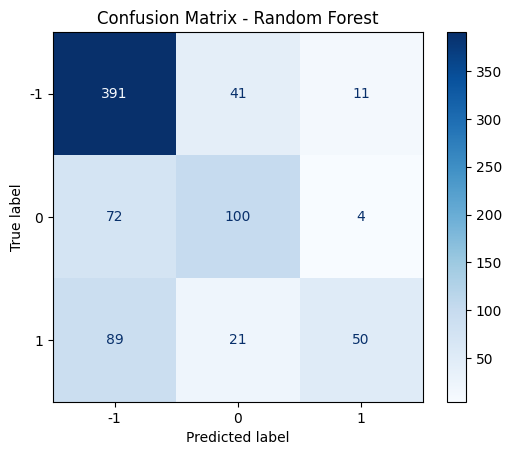

In [9]:
cm_rf = confusion_matrix(y_test, y_pred_rf)
disp_rf = ConfusionMatrixDisplay(confusion_matrix=cm_rf, display_labels=[-1, 0, 1])
disp_rf.plot(cmap="Blues", values_format="d")
plt.title("Confusion Matrix - Random Forest")
plt.show()

In [10]:
results = pd.DataFrame({
    "Model": ["Logistic Regression", "SVM (LinearSVC)", "Random Forest"],
    "Accuracy": [accuracy, svm_accuracy, rf_accuracy],
    "Precision": [precision, report_df.loc["weighted avg","precision"], rf_precision],
    "Recall":    [recall,    report_df.loc["weighted avg","recall"],    rf_recall],
    "F1-score":  [f1,        report_df.loc["weighted avg","f1-score"],  rf_f1]
})

results = results.round(4)
results_sorted = results.sort_values(by="F1-score", ascending=False)
best_model     = results_sorted.iloc[0]

print("="*60)
print("MODEL COMPARISON RESULTS")
print("="*60)
print(results_sorted)
print("\n" + "="*60)
print("BEST PERFORMING MODEL (Based on F1-score)")
print("="*60)
print(best_model)

MODEL COMPARISON RESULTS
                 Model  Accuracy  Precision  Recall  F1-score
1      SVM (LinearSVC)    0.7227     0.7187  0.7227    0.7201
0  Logistic Regression    0.7112     0.7197  0.7112    0.7142
2        Random Forest    0.6945     0.7003  0.6945    0.6719

BEST PERFORMING MODEL (Based on F1-score)
Model        SVM (LinearSVC)
Accuracy              0.7227
Precision             0.7187
Recall                0.7227
F1-score              0.7201
Name: 1, dtype: object


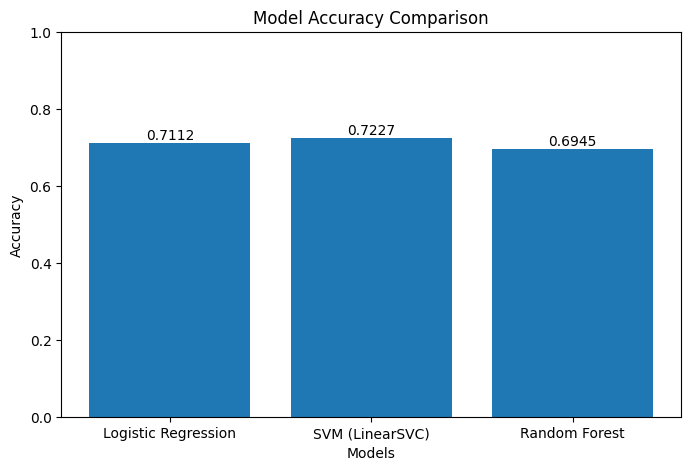

In [11]:
accuracies = [accuracy, svm_accuracy, rf_accuracy]
models_list = ["Logistic Regression", "SVM (LinearSVC)", "Random Forest"]

plt.figure(figsize=(8,5))
plt.bar(models_list, accuracies)
plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")
plt.ylim(0, 1)
for i, v in enumerate(accuracies):
    plt.text(i, v + 0.01, str(round(v, 4)), ha='center')
plt.show()

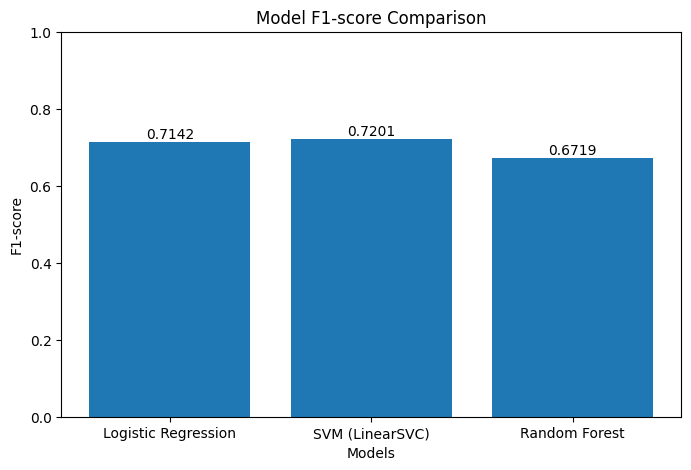

In [12]:
f1_scores = [f1, report_df.loc["weighted avg","f1-score"], rf_f1]

plt.figure(figsize=(8,5))
plt.bar(models_list, f1_scores)
plt.title("Model F1-score Comparison")
plt.xlabel("Models")
plt.ylabel("F1-score")
plt.ylim(0, 1)
for i, v in enumerate(f1_scores):
    plt.text(i, v + 0.01, str(round(v, 4)), ha='center')
plt.show()

Model Selection: SVM (LinearSVC)
Based on the evaluation results, the SVM (LinearSVC) model was selected as the best performing model for sentiment classification. It achieved the highest accuracy of 72.27% and the highest F1-score of 0.7201 compared to Logistic Regression (F1=0.7142) and Random Forest (F1=0.6719). SVM demonstrated more balanced performance across all three sentiment classes (negative, neutral, positive), with stronger recall on the negative class (0.82). Additionally, SVM is well-suited for text classification tasks with high-dimensional TF-IDF features, as it effectively finds the optimal decision boundary between classes. Therefore, SVM was chosen as the final model for predicting sentiment in vaccine-related comments and news articles.

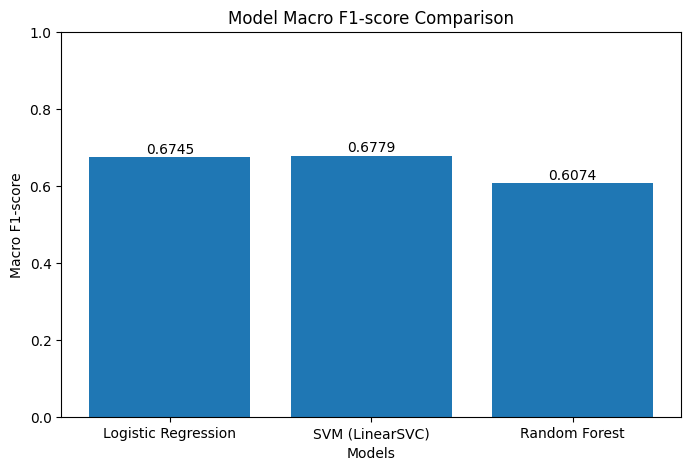

In [13]:
# Macro F1-score comparison

macro_f1_scores = [

    lr_report["macro avg"]["f1-score"],

    svm_report["macro avg"]["f1-score"],

    rf_report["macro avg"]["f1-score"]

]



plt.figure(figsize=(8,5))

plt.bar(models_list, macro_f1_scores)

plt.title("Model Macro F1-score Comparison")

plt.xlabel("Models")

plt.ylabel("Macro F1-score")

plt.ylim(0, 1)



for i, v in enumerate(macro_f1_scores):

    plt.text(i, v + 0.01, str(round(v, 4)), ha="center")



plt.show()

Since the dataset is imbalanced, accuracy alone is not a reliable metric. Therefore, we used the macro F1-score to evaluate model performance, as it considers both precision and recall while giving equal importance to all classes. Based on the macro F1-score comparison, the SVM (LinearSVC) model achieved the highest performance with a score of approximately 0.6779, followed closely by Logistic Regression with 0.6745, while Random Forest showed the lowest performance at 0.6074. This indicates that SVM provides the most balanced performance across the three sentiment classes (negative, neutral, and positive). Although the difference between SVM and Logistic Regression is small, SVM still performs slightly better overall and was therefore selected as the best model for this task.